Using INR for jan model

torch has `cpu` version and `cuda` version, the default is `cpu` version, it is enough for such a simple demo, but directly install `cuda` version is recommeded

In [1]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pyvista as pv
import pyvistaqt as pvqt
import pandas as pd
import time
import torch.autograd as autograd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
torch.cuda.is_available()

False

In [3]:
torch.manual_seed(0)

input data

gempy input style

In [4]:
data_path = 'https://raw.githubusercontent.com/cgre-aachen/gempy_data/master/'
path_to_data = data_path + "data/input_data/jan_models/"
path_to_orientations=path_to_data + "model2_orientations.csv",
path_to_surface_points=path_to_data + "model2_surface_points.csv"
orientations = pd.read_csv(path_to_orientations[0])
surface_points = pd.read_csv(path_to_surface_points)
extents=[0, 1000, 0, 1000, 0, 1000]

convert to INR input style

In [5]:
orientations = orientations[['X', 'Y', 'Z']].values
orientations = np.hstack([orientations, [[0,0,1]]*len(orientations)]) # convert dip and azimuth to normal vector

surface_points['label'] = np.where(surface_points['formation'] == 'rock1', -1, 1)  # assign labels to surface points
surface_points = surface_points[['label', 'X', 'Y', 'Z']].values  # labels in the first column

In [6]:
orientations

array([[500, 500, 820,   0,   0,   1],
       [500, 500, 620,   0,   0,   1]])

interpolated mesh data

In [7]:
resolution = [100, 100, 100]
test_data = pv.ImageData()  # in old pyvista versions, this was pv.UniformGrid()
test_data.dimensions = resolution
test_data.origin = [extents[0], extents[2], extents[4]]
test_data.spacing = [(extents[1]-extents[0])/(resolution[0]-1), (extents[3]-extents[2])/(resolution[1]-1), (extents[5]-extents[4])/(resolution[2]-1)]
test_xyz = test_data.points

In [33]:
test_xyz.shape

(1000000, 3)

normalize the coordinates into range [-1, 1]

In [9]:
def normalize(data, bounds):
    """
    Normalize the data to [-1, 1]
    data: the data to be normalized
    bounds: the extent of the model domain
    """
    data = data.astype(np.float32)
    mean_x = (bounds[0] + bounds[1]) / 2
    mean_y = (bounds[2] + bounds[3]) / 2
    mean_z = (bounds[4] + bounds[5]) / 2
    delta_x = bounds[1] - bounds[0]
    delta_y = bounds[3] - bounds[2]
    delta_z = bounds[5] - bounds[4]
    data[:, 0] = (data[:, 0] - mean_x) / delta_x * 2
    data[:, 1] = (data[:, 1] - mean_y) / delta_y * 2
    data[:, 2] = (data[:, 2] - mean_z) / delta_z * 2

    return data

INR structure

In [10]:
# used in implicit neural representation
class ConcatMLP(nn.Module):
    """
    concatenate the input features with the hidden layer features as an enhanced feature
    the neural network structure is flexible, where
    in_dim: the input dimension, the coodinates plus fault features
    hidden_dim: the hidden layer dimension
    out_dim: the output dimension, a scalar value
    n_hidden_layers: the number of hidden layers
    activation: the activation function
    beta: the beta parameter in the Softplus activation function, effective when the activation function is Softplus
    concat: whether to concatenate the input features with the hidden layer features
    """
    def __init__(self,
                 in_dim,
                 hidden_dim,
                 out_dim,
                 n_hidden_layers,
                 activation,
                 beta, 
                 concat):
        super(ConcatMLP, self).__init__()
        self.layers = nn.ModuleList()
        self.beta = beta
        if activation == 'Softplus':
            self.activation = nn.Softplus(beta=self.beta)
        elif activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'LeakyReLU':
            self.activation = nn.LeakyReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        elif activation == 'Sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'ELU':
            self.activation = nn.ELU()
        elif activation == 'PReLU':
            self.activation = nn.PReLU()
        else:
            print('Activation function not recognized. Using Softplus, ReLU, LeakyReLU, Tanh, Sigmoid, ELU.')
        self.num_layers = 2 + n_hidden_layers
        self.concat = concat

        # input layer
        self.layers.append(nn.Linear(in_dim, hidden_dim))

        if self.concat:
            # hidden layers
            h_dim_concat = in_dim + hidden_dim
            for i in range(n_hidden_layers):
                self.layers.append(nn.Linear(h_dim_concat, h_dim_concat))
                #h_dim_concat *= 2  # concatenate all the former layer's features 
                h_dim_concat = in_dim + h_dim_concat # only concatenate the input with the hidden layer features
            # output layer
            self.layers.append(nn.Linear(h_dim_concat, out_dim))

        else:
            # hidden layers
            for i in range(n_hidden_layers):
                self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            # output layer
            self.layers.append(nn.Linear(hidden_dim, out_dim))
    
    def forward(self, x):
        x_target = x  # Keep the original input features for concatenation

        for i, layer in enumerate(self.layers):
            x = layer(x)
            
            # Only apply activation and concatenation to hidden layers (not the last layer)
            if i < len(self.layers) - 1:
                if self.concat:
                    # Concatenate the input with the hidden layer output
                    x = torch.cat((x_target, x), dim=1)
                x = self.activation(x)
        
        return x

define loss functions for the training process

In [11]:
# loss function for the interface points
def loss_intf(y_pred, y_true):
    #criterion = nn.MSELoss()
    #criterion = nn.MSELoss(reduction='sum')
    criterion = nn.L1Loss()
    #criterion = nn.SmoothL1Loss(reduction='sum')

    return criterion(y_pred, y_true)

# loss function for the orientation points
def loss_grad(train_x, y_pred, y_true, n_orien):
    """
    train_x: the input data, includes the interface points and orientation points, the orientaion points are at the end of the input data
             train_x = [interface points, orientation points]
    y_pred: the predicted orientation
    y_true: the true orientation
    n_orien: the number of orientation points
    """
    gradients = autograd.grad(outputs=y_pred, inputs=train_x, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
    grad_norm_pred = torch.norm(gradients[-n_orien:,:], p=2, dim=1)
    grad_inner_product = torch.einsum('ij, ij->i', y_true, gradients[-n_orien:,:])
    cosine = grad_inner_product / grad_norm_pred  # orie_tensor using normal orientation
    #loss_grad = torch.sum(1 - cosine)
    loss_grad = torch.mean(1 - cosine)

    return loss_grad

define the function to generate predicted mesh

In [12]:
def predict_to_mesh_stratigraphic(extents, resolution, predictions, iso_values):
    """
    the prediction results of gridmesh points are assigned back to the gridmesh points under the same resolution
    multiple isovalues are used to generate the stratigraphic surfaces according to the 'iso_values'
    extents: the extent of the model domain
    resolution: the resolution of the model
    predictions: the prediction results of the gridmesh points
    """
    grid_mesh_final = pv.ImageData()
    grid_mesh_final.dimensions = resolution
    grid_mesh_final.origin = [extents[0], extents[2], extents[4]]
    grid_mesh_final.spacing = [(extents[1]-extents[0])/(resolution[0]-1), (extents[3]-extents[2])/(resolution[1]-1), (extents[5]-extents[4])/(resolution[2]-1)]

    grid_mesh_final.point_data['scalar'] = predictions.ravel()
    contours_mean = grid_mesh_final.contour(isosurfaces=iso_values) 

    return contours_mean, grid_mesh_final

model training

In [13]:
def stratigraphic_ConcatMLP(interface_data, orientation_data, meshgrid_data, extent, resolution, in_dim, hidden_dim, out_dim,
                    n_hidden_layers, activation='Softplus', beta=1, concat=False, epochs=2000, lr=0.001, alpha=0.1):
    """
    Notes: 1. this function is used to model the stratigraphic surfaces, fault feature encoding for this purpose
           2. use 'autograd' to calculate the orientation gradient
    interface_data: the data comes from the feature encoding results, the list is [label, x, y, z, fault1, fault2, ...], 
                    label value in range [-1, 1], fault1, fault2 are the fault feature encoding results
    orientation_data: the data comes from the feature encoding results, the list is [x, y, z, dx, dy, dz, fault1, fault2, ...],
    meshgrid_data: the meshgrid points for predicting the domain, the format is [x, y, z, fault1, fault2, ...]
    extent: the extent of the model
    resolution: the resolution of the model
    in_dim: the input dimension of the neural network
    hidden_dim: the hidden layer dimension
    out_dim: the output dimension, a scalar value
    n_hidden_layers: the number of hidden layers
    activation: the activation function, default is 'Softplus'
    beta: the beta parameter in the Softplus activation function, effective when the activation function is Softplus
    concat: whether to concatenate the input features with the hidden layer features
    epochs: the number of epochs for training the model
    lr: the learning rate for training the model
    delta_orie: the delta value for calculating the orientation gradient, set as 1 means the gradient is calculated by the difference of 1 cell
    alpha: the weight of the orientation loss, default is 0.1
    """
    # read the data
    # train_data_x = interface_data[:, 1:].astype(np.float)
    # train_data_y = interface_data[:, 0].astype(np.float)
    # train_orie_x = orientation_data[:,0:3].astype(np.float) 
    # train_orie_y = orientation_data[:,3:6].astype(np.float)
    train_data_x = interface_data[:, 1:].astype("float")
    train_data_y = interface_data[:, 0].astype("float")
    train_orie_x = orientation_data[:,0:3].astype("float") 
    train_orie_y = orientation_data[:,3:6].astype("float")
    # normalize the data
    normalized_train_data_x = normalize(train_data_x, extent)
    normalized_train_orie_x = normalize(train_orie_x, extent)
    normalized_meshgrid_data = normalize(meshgrid_data, extent)

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    # concatenate the interface points and orientation points for training
    train_x_dx = np.vstack((normalized_train_data_x, normalized_train_orie_x))
    # convert to torch tensor and send to GPU
    x_dx_tensor = torch.tensor(train_x_dx, dtype=torch.float32).to(device).requires_grad_(True)
    y_tensor = torch.tensor(train_data_y, dtype=torch.float32).to(device)
    dy_tensor = torch.tensor(train_orie_y, dtype=torch.float32).to(device)
    test_x_tensor = torch.tensor(normalized_meshgrid_data, dtype=torch.float32).to(device)
    # the number of interface points and orientation points for dividing the input tensor to send to loss functions
    n_intf = normalized_train_data_x.shape[0]
    n_orie = normalized_train_orie_x.shape[0]
    # train the model
    model = ConcatMLP(in_dim=in_dim,
                        hidden_dim=hidden_dim,
                        out_dim=out_dim,
                        n_hidden_layers=n_hidden_layers,
                        activation=activation,
                        beta=beta,
                        concat=concat,
                        ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)  #Adam
    # Initialize variables to track minimum loss and corresponding parameters
    min_loss = float('inf')
    best_params = None

    t1_train = time.time()
    for epoch in range(epochs):
        y_pred = model(x_dx_tensor)  
        # calculate the interface loss
        loss_i = loss_intf(y_pred[:n_intf,:].squeeze(), y_tensor)
        # calculate the orientation loss
        loss_o = loss_grad(x_dx_tensor, y_pred, dy_tensor, n_orie)
        loss = loss_i + alpha * loss_o
        if loss < min_loss:
            min_loss = loss
            # Save the current parameters of the model
            best_params = model.state_dict()
            min_loss_i = loss_i
            min_loss_o = loss_o
        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()
    t2_train = time.time()
    
    print(f'Training losses | Loss_i: {min_loss_i.item()}, Loss_o: {min_loss_o.item()}')
    print(f'each epoch training time :  {(t2_train - t1_train) / epochs} seconds')
    # model for inference
    best_model = ConcatMLP(in_dim=in_dim,
                        hidden_dim=hidden_dim,
                        out_dim=out_dim,
                        n_hidden_layers=n_hidden_layers,
                        activation=activation,
                        beta=beta,
                        concat=concat,
                        ).to(device)
    best_model.load_state_dict(best_params)
    # Predict with the model
    with torch.no_grad():
        t1_inference = time.time()
        predictions = best_model(test_x_tensor).cpu().numpy()
        t2_inference = time.time()
    # convert to pyvista mesh
    # get the iso values for extracting the stratigraphic surfaces
    iso_values = np.unique(interface_data[:, 0])
    stratigraphic_mesh, grid_mesh_final = predict_to_mesh_stratigraphic(extent, resolution, predictions, iso_values)
    print(f'Inference time: {t2_inference - t1_inference} seconds')
    print('------Finish-------')
    
    return stratigraphic_mesh, grid_mesh_final

In [14]:
stratigraphic_mesh, scalar_field_strats = stratigraphic_ConcatMLP(interface_data=surface_points,  # stratigraphic points with labels
                                            orientation_data=orientations,        # orientation points
                                            meshgrid_data=test_xyz,               # meshgrid points of interpreated domain
                                            extent=extents,                       # domain boundary
                                            resolution=resolution,                # resolution of the domain mesh
                                            in_dim=3,                             # input dimension of neural network
                                            hidden_dim=32,                        # hidden layer's dimension of neural network
                                            out_dim=1,                            # output dimension of neural network, the only output is a scalar value
                                            n_hidden_layers=1,                    # number of hidden layers
                                            activation='Softplus',                # activation function, default is 'Softplus'
                                            beta=10,                              # `beta` value for Softplus activation function
                                            concat=False,                         # whether to concat the input features to hidden layers
                                            epochs=1000,                          # number of forward and backward propagation process
                                            lr=0.01)                              # learning rate     

Training losses | Loss_i: 0.00703201349824667, Loss_o: 2.2351741790771484e-05
each epoch training time :  0.0023039913177490233 seconds
Inference time: 0.16601943969726562 seconds
------Finish-------


plot the stratigraphics

In [31]:
def plot_stratigraphic(scalar_field):
    """
    visualize the stratigraphic units, the scalar field is thresholded to get the stratigraphic model
    scalar_field: the 3D scalar field
    *** only for case 1 ***
    """
    # p_stratigraphic = pvqt.BackgroundPlotter()
    p_stratigraphic = pv.Plotter()

    scalar = scalar_field.point_data['scalar'] 
    scalar = np.where(scalar >= 1, 3, scalar)
    scalar = np.where((scalar < 1) & (scalar >= -1), 2, scalar)
    scalar = np.where(scalar < -1, 1, scalar)
    scalar_field.point_data['Rock types'] = scalar.astype(int).ravel()

    viridis = plt.cm.get_cmap('viridis', 256)  # full 'viridis' colormap
    # 25% - 75% of the 'viridis' colormap
    middle_colors = viridis(np.linspace(0.15, 1, 256))
    custom_cmap = ListedColormap(middle_colors)

    # change the color bar 
    scalar_bar_args = {
    'title_font_size': 25,   
    'label_font_size': 25,
    'vertical': False,
    #'n_colors': 256,
    'fmt': '%.2f',
    'position_x': 0.34,
    'position_y': 0.11,
    'width': 0.55,
    'height': 0.08,
    'n_labels': 5,
    'font_family': 'arial',
    }
    p_stratigraphic.add_mesh(scalar_field, opacity=1, scalars='Rock types', cmap=custom_cmap, scalar_bar_args=scalar_bar_args)

    p_stratigraphic.add_bounding_box(color='black', line_width=2.0)
    p_stratigraphic.add_axes(line_width=3, viewport=(0, 0, 0.3, 0.25))

    return p_stratigraphic.show()

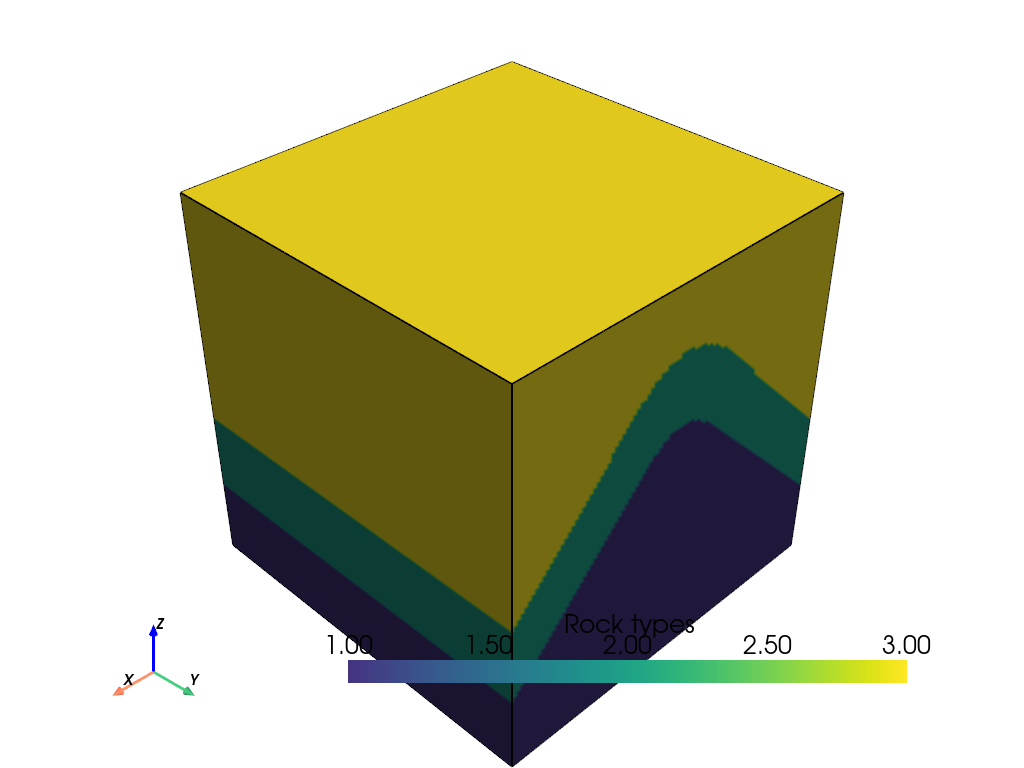

In [32]:
plot_stratigraphic(scalar_field_strats)

plot the interfaces

In [36]:
scalar_field_strats["scalar"].shape

(1000000,)

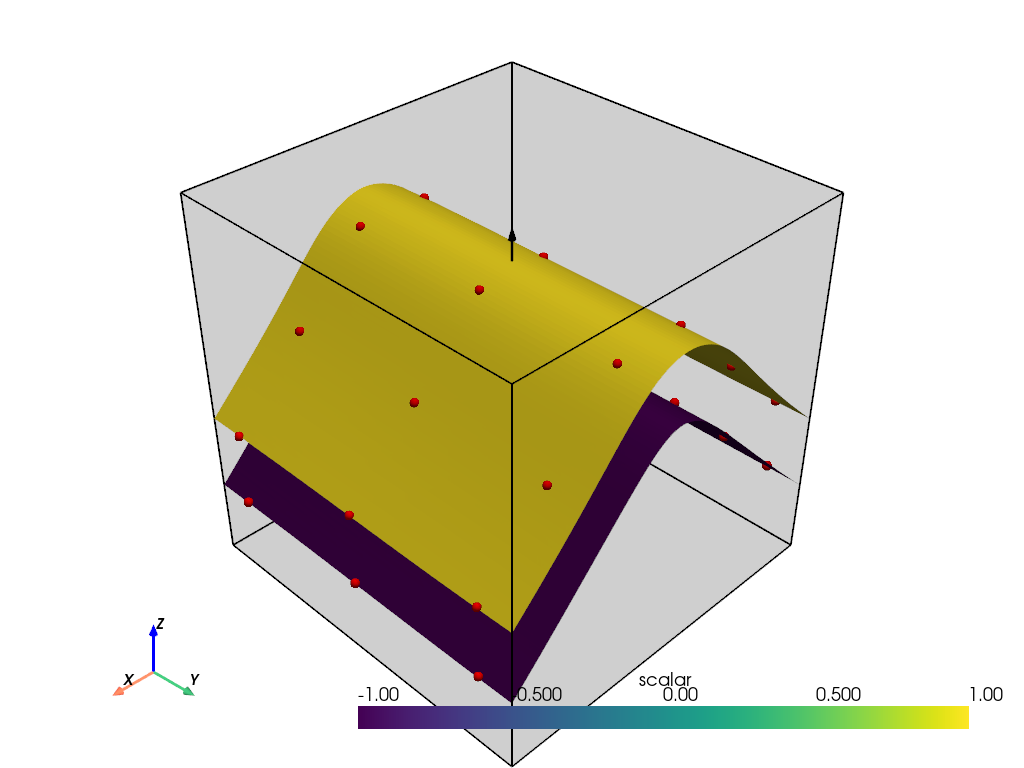

In [26]:
pp = pv.Plotter()
pp.add_mesh(stratigraphic_mesh, opacity=1)
pp.add_points(surface_points[:, 1:], color='red', point_size=10, render_points_as_spheres=True)
pp.add_arrows(orientations[:, :3], orientations[:, 3:], mag=100, color='black')
pp.add_mesh(pv.Box(bounds=[extents[0], extents[1], extents[2], extents[3], extents[4], extents[5]]), color='k', opacity=0.1)
pp.add_bounding_box(color='black', line_width=2.0)
pp.add_axes(line_width=3, viewport=(0, 0, 0.3, 0.25))
pp.show(jupyter_backend='trame')